<a href="https://colab.research.google.com/github/anamadot/CPE310-IE22S1/blob/main/Netflix_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Case Study**

---
**Group Members:** <br>
>Calma, Christian John <br>
>Ibarra, Ana Ma. Alexandra <br>
>Jeolin, Cholo <br>
>Juarez, Wenilyn <br>
>Yusiang, Azriel <br>

**Course & Section:** CPE 310-IE22S1 <br>
**Course Name:** Fundamentals of Data Science <br>
**Date:** April 23, 2026

---

**1. Data Loading & Overview**

In [ ]:
#import the libraries
import pandas as pd
netflix = pd.read_csv('/content/netflix_titles.csv')

#Dimensions
netflix.shape

(8807, 12)

In [ ]:
#First 5 rows
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
#Last 5 rows
netflix.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


This dataset containes 8807 entries, each with 12 categories of information about Netflix content, but a significant amount of data is missing, particularly for the director, country, and cast. The entries cover a variety if content types like movies and TV shows, with diverse release years, ratings, and durations, each accompanied by a brief doscription.

**2. Data Cleaning**

In [ ]:
#Missing Values
netflix.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
#Fill placeholders on missing values under director, cast, and country

netflix['director'] = netflix['director'].fillna('Unknown')
netflix['cast'] = netflix['cast'].fillna('Unknown')
netflix['country'] = netflix['country'].fillna('Unknown')

In [ ]:
#Dropping rows with missing values under date_added, rating, and duration

netflix = netflix.dropna(subset=['date_added', 'rating', 'duration'])

**3. Data Types & Conversion**





In [ ]:
#Checking Data Types

netflix.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [ ]:
#Converting to datetime

netflix['date_added'] = netflix['date_added'].apply(pd.to_datetime)
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**4. Univariate Analysis**

In [ ]:
#Movies vs. TV Shows

netflix.type.value_counts()

,count
type,
Movie,6126
TV Show,2664


In [ ]:
#Top 5 Most Common Ratings

netflix.rating.value_counts().head()

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490


In [ ]:
#Frequent Release Years

netflix.release_year.value_counts()

,count
release_year,
2018,1146
2017,1030
2019,1030
2020,953
2016,901
...,...
1961,1
1925,1
1959,1


**5. Duration & Seasons**

In [ ]:
#Converting duration for movies into numeric minutes

movies = netflix[(netflix.type == 'Movie')]
movies['duration'] = movies['duration'].str.strip(' min').astype(int)
movies.head()

/tmp/ipykernel_7767/2237569054.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration'] = movies['duration'].str.strip(' min').astype(int)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127,"Dramas, International Movies",After most of her family is murdered in a terr...


In [ ]:
#Average length duration for Movies

movies['duration'].mean()

np.float64(99.58488410055502)

In [ ]:
#Converting duration for TV shows into number of seasons

tvshow = netflix[(netflix.type == 'TV Show')]
tvshow['duration'] = tvshow['duration'].str.split(' ').str[0].astype(int)
tvshow.head()


/tmp/ipykernel_7767/3656639270.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tvshow['duration'] = tvshow['duration'].str.split(' ').str[0].astype(int)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...


In [ ]:
#Average number of seasons for TV Shows

tvshow['duration'].mean()

np.float64(1.7518768768768769)

**6. Genre Analysis**

In [ ]:
#Separating genres to different rows

netflix['listed_in'] = netflix['listed_in'].str.split(', ')
netflix = netflix.explode('listed_in')
netflix.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,International TV Shows,To protect his family from a powerful drug lor...
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,TV Action & Adventure,To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,Docuseries,"Feuds, flirtations and toilet talk go down amo..."
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,Reality TV,"Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,In a city of coaching centers known to train I...


In [ ]:
#Genre with highest average release year

netflix.groupby('listed_in')['release_year'].mean().sort_values(ascending = False).head()

,release_year
listed_in,
TV Mysteries,2018.346939
TV Horror,2018.200000
Reality TV,2017.894118
Stand-Up Comedy & Talk Shows,2017.857143
TV Thrillers,2017.736842


This indicates that the code is separating content into individual genres and then calculating the average release year for each genre, suggesting that genres like TV Mysteries, TV Horror, and Reality TV have been present on Netflix for a longer average duration compared to others.

**7. Temporal Trends**

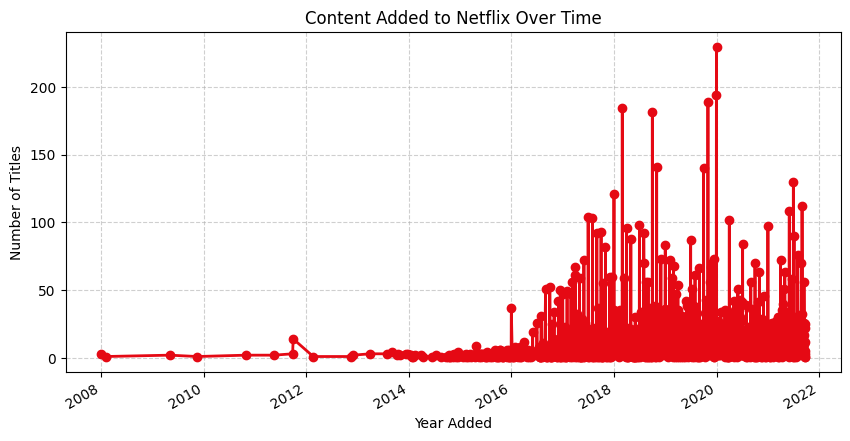

In [ ]:
import matplotlib.pyplot as plt

# Count titles per year added
yearly_counts = netflix['date_added'].value_counts().sort_index()

# Plotting
plt.figure(figsize=(10, 5))
yearly_counts.plot(kind='line', marker='o', color='#E50914', linewidth=2)
plt.title('Content Added to Netflix Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

count    8709.000000
mean        4.690894
std         8.792208
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: acquisition_delay, dtype: float64


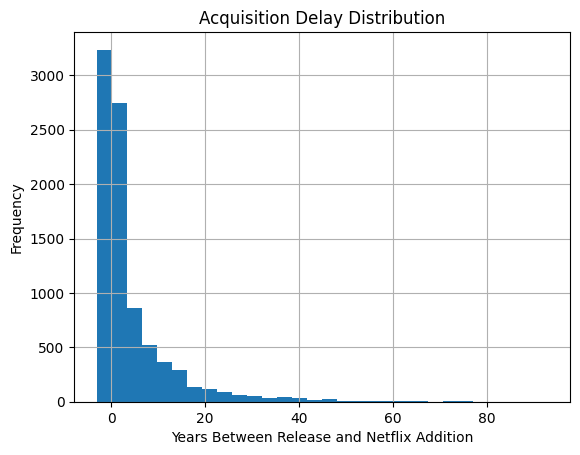

Average acquisition delay: 4.69 years


In [ ]:
netflix['acquisition_delay'] = netflix['year_added'] - netflix['release_year']

delay_df = netflix.dropna(subset=['acquisition_delay'])

print(delay_df['acquisition_delay'].describe())

plt.figure()
delay_df['acquisition_delay'].hist(bins=30)
plt.xlabel('Years Between Release and Netflix Addition')
plt.ylabel('Frequency')
plt.title('Acquisition Delay Distribution')
plt.show()

avg_delay = delay_df['acquisition_delay'].mean()
print(f"Average acquisition delay: {avg_delay:.2f} years")

**8. Rating vs. Type**

In [ ]:
#Crosstab

pd.crosstab(netflix['type'], netflix['rating'])

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
type,,,,,,,,,,,,,,
Movie,73,7,154,607,998,1578,3462,263,4445,1208,165,207,10,8
TV Show,0,0,11,0,0,4,1777,196,2861,697,240,320,3,0


**9. Filtering & Querying**





In [ ]:
#Getting only the year from date_added

netflix['date_added'].dt.year
netflix.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,object


In [ ]:
#Titles with R rating added after 2020

netflix.query("date_added > 2020 and rating == 'R'")['title']

,title
46,Safe House
46,Safe House
46,Safe House
48,Training Day
48,Training Day
...,...
8703,We Are Your Friends
8703,We Are Your Friends
8703,We Are Your Friends
8703,We Are Your Friends


In [ ]:
# 2. Apply the double filter
# We look for Rating 'R' AND Year Added > 2020
r_rated_recent = netflix[(netflix['rating'] == 'R') & (netflix['date_added'].dt.year > 2020)]
r_rated_recent.shape[0]


545

**10. Aggregations & GroupBy**

For each country, compute the average release year of its titles.

In [ ]:
#Separating Countries

netflix['country'] = netflix['country'].str.split(', ')
netflix = netflix.explode('country')
netflix.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,International TV Shows,To protect his family from a powerful drug lor...
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,TV Action & Adventure,To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,Docuseries,"Feuds, flirtations and toilet talk go down amo..."
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,Reality TV,"Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,In a city of coaching centers known to train I...


In [ ]:
#Average release year per country

netflix.groupby('country')['release_year'].mean().sort_values(ascending=False)

,release_year
country,
Angola,2020.000000
Cameroon,2020.000000
Mauritius,2020.000000
Cayman Islands,2019.500000
Palestine,2019.000000
...,...
Soviet Union,1985.000000
West Germany,1977.454545
"Poland,",1975.000000


In [ ]:
us_titles_years = netflix[netflix['country'].str.contains('United States', na=False)][['title', 'release_year']]

# Display the first 10 results
print(us_titles_years.head(10))

                   title  release_year
0   Dick Johnson Is Dead          2020
7                Sankofa          1993
7                Sankofa          1993
7                Sankofa          1993
9           The Starling          2021
9           The Starling          2021
15     Dear White People          2021
15     Dear White People          2021
27             Grown Ups          2010
28            Dark Skies          2013


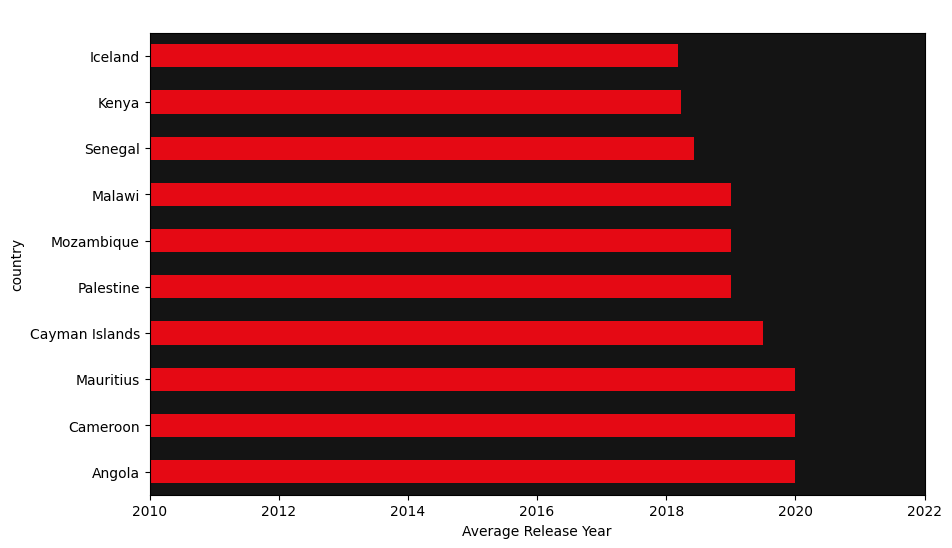

In [ ]:
avg_year_country = netflix.groupby('country')['release_year'].mean().sort_values(ascending=False)

# 2. Plot the Top 10
plt.figure(figsize=(10, 6), facecolor='#FFFFFF')
ax = avg_year_country.head(10).plot(kind='barh', color='#E50914')
ax.set_facecolor('#141414')

plt.title('Top 10 Countries by Content Freshness', color='white', fontsize=14)
plt.xlabel('Average Release Year', color='black')
plt.xlim(2010, 2022) # Zoom in to see the differences
plt.show()

In [ ]:
#Proportion of Movies vs. TV Shows added each year

netflix.groupby(netflix['date_added'].dt.year)['type'].value_counts(normalize=True)

date_added  type   
2008        Movie      0.750000
            TV Show    0.250000
2009        Movie      1.000000
2010        Movie      1.000000
2011        Movie      1.000000
2012        Movie      1.000000
2013        TV Show    0.655172
            Movie      0.344828
2014        Movie      0.679245
            TV Show    0.320755
2015        Movie      0.665025
            TV Show    0.334975
2016        Movie      0.558770
            TV Show    0.441230
2017        Movie      0.716450
            TV Show    0.283550
2018        Movie      0.767893
            TV Show    0.232107
2019        Movie      0.719415
            TV Show    0.280585
2020        Movie      0.699728
            TV Show    0.300272
2021        Movie      0.689472
            TV Show    0.310528
Name: proportion, dtype: float64

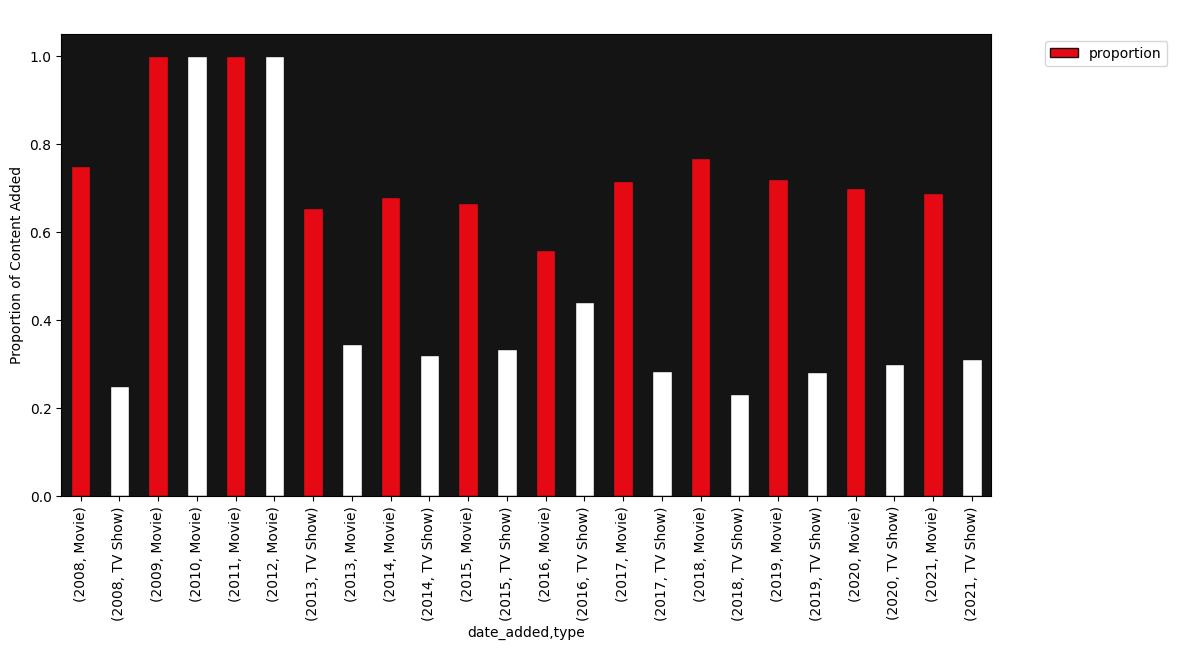

In [ ]:
proportion_table.plot(kind='bar',
                      stacked=True,
                      figsize=(12, 6),
                      color=['#E50914', '#ffffff'], # Netflix Red and White
                      edgecolor='#141414')

plt.title('Netflix Strategy Shift: Movies vs TV Shows (%)', fontsize=16, color='white')
plt.gca().set_facecolor('#141414') # Matching your dark theme
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('Proportion of Content Added')
plt.show()

In [ ]:
def get_titles_by_director(netflix, director_name):
    director_df = netflix[netflix['director'].str.contains(director_name, na=False)]
    director_df = director_df.sort_values(by='release_year')
    return director_df[['title', 'release_year']]

get_titles_by_director(netflix, "Steven Spielberg")

,title,release_year
41,Jaws,1975
7072,Indiana Jones and the Raiders of the Lost Ark,1981
7073,Indiana Jones and the Temple of Doom,1984
7071,Indiana Jones and the Last Crusade,1989
7957,Schindler's List,1993
329,Catch Me If You Can,2002
7070,Indiana Jones and the Kingdom of the Crystal S...,2008
8184,The Adventures of Tintin,2011
8696,War Horse,2011
7308,Lincoln,2012


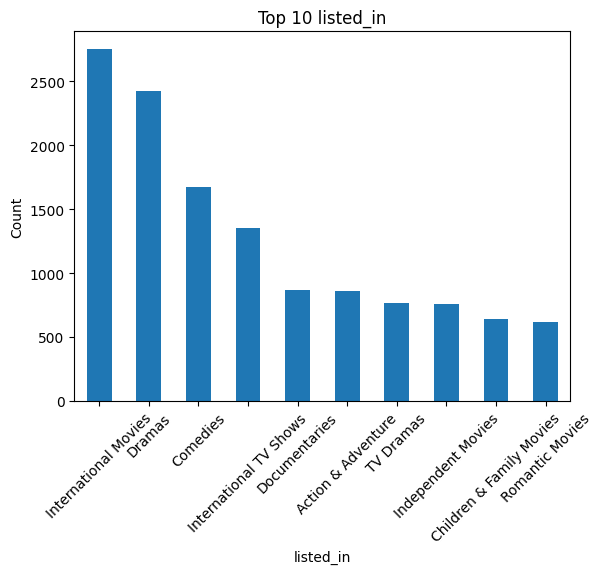

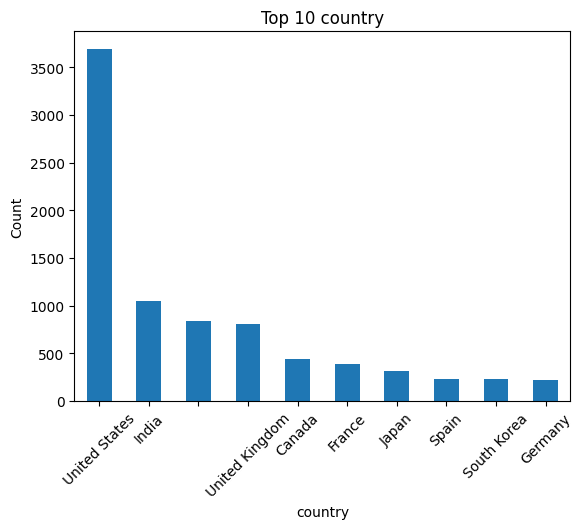

In [ ]:
def plot_top_categories(netflix, column, top_n=10):
    temp_df = netflix.copy()
    temp_df[column] = temp_df[column].fillna('')

    exploded = temp_df.assign(**{
        column: temp_df[column].str.split(',')
    }).explode(column)

    exploded[column] = exploded[column].str.strip()

    top_counts = exploded[column].value_counts().head(top_n)

    plt.figure()
    top_counts.plot(kind='bar')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.title(f'Top {top_n} {column}')
    plt.xticks(rotation=45)
    plt.show()

plot_top_categories(netflix, 'listed_in', 10)
plot_top_categories(netflix, 'country', 10)